# Trend-aware fuzzy time-series forecasting: a multi-horizon experiment

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/D2718281828nis/Fuzzy-Regression/blob/master/example-Fuzzy-timeseries-forecast.ipynb)

This notebook implements a **trend-aware** fuzzy time series (FTS) from first principles and compares it with transparent baselines. Instead of fuzzifying enrollment levels—which makes recursive predictions settle on an interval midpoint—the model fuzzifies yearly **changes** and adds each predicted change to the last level. We evaluate 1-, 2-, and 3-step-ahead forecasts with a leakage-free rolling origin, then inspect a five-year forecast from 1987.

> **Question.** Can fuzzy rules learned from historical changes continue a rising or falling trend instead of producing an unrealistic horizontal forecast?

In [14]:
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=2, suppress=True)

## 1. Data and experimental design

The classic University of Alabama enrollment series contains only 22 annual observations. We therefore avoid a single hand-picked split. At every rolling origin, all model parameters—including the fuzzy universe and rules—are re-estimated using the available prefix only. The following 1–3 observations remain hidden for testing.

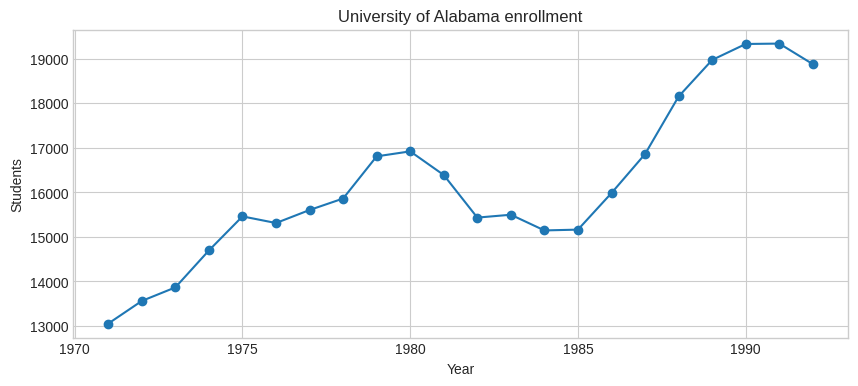

,enrollment
1988,18150.0
1989,18970.0
1990,19328.0
1991,19337.0
1992,18876.0


In [15]:
years = np.arange(1971, 1993)
values = np.array([
    13055, 13563, 13867, 14696, 15460, 15311, 15603, 15861,
    16807, 16919, 16388, 15433, 15497, 15145, 15163, 15984,
    16859, 18150, 18970, 19328, 19337, 18876,
], dtype=float)
series = pd.Series(values, index=years, name="enrollment")

ax = series.plot(marker="o", figsize=(10, 4), title="University of Alabama enrollment")
ax.set(xlabel="Year", ylabel="Students")
plt.show()
series.to_frame().tail()

## 2. Trend-aware, recency-weighted FTS

A level-based FTS maps a recursive forecast back to a finite level interval. It can quickly enter a self-transition and become horizontal. Here we instead model first differences, `d(t) = y(t) - y(t-1)`. The forecast reconstructs the level as `y_hat(t+1) = y_hat(t) + d_hat(t+1)`, so learned positive/negative changes continue the corresponding direction.

We pad the training-change range by 10%, divide it into equal intervals, and represent each interval by its midpoint. Assigning a change to the nearest midpoint is the maximum-membership choice for regular overlapping triangular sets.

A model of order 1 learns `D(t-1) -> D(t)`; order 2 learns `(D(t-2), D(t-1)) -> D(t)`. Transition weights decay with age, so recent historical behavior matters more while older transitions still contribute. Defuzzification is the weighted mean of consequent change-set midpoints. The order-2 model backs off to its first-order table for an unseen pair, and finally to a recency-weighted mean of the last changes. Forecasts are recursive and never use actual values beyond the origin.

In [16]:
class TrendWeightedFTS:
    """Recency-weighted FTS over first differences, reconstructed to levels."""

    def __init__(self, n_intervals=7, order=1, padding=0.10, decay=0.90):
        if order not in (1, 2):
            raise ValueError("order must be 1 or 2")
        if not 0 < decay <= 1:
            raise ValueError("decay must be in (0, 1]")
        self.n_intervals = n_intervals
        self.order = order
        self.padding = padding
        self.decay = decay

    def fit(self, y):
        y = np.asarray(y, dtype=float)
        changes = np.diff(y)
        if changes.size <= self.order:
            raise ValueError("The training series is too short for this order")
        span = np.ptp(changes) or max(abs(changes[0]), 1.0)
        lo = changes.min() - self.padding * span
        hi = changes.max() + self.padding * span
        edges = np.linspace(lo, hi, self.n_intervals + 1)
        self.centers_ = (edges[:-1] + edges[1:]) / 2
        states = self._fuzzify(changes)
        self.rules_ = self._make_rules(states, self.order)
        self.backoff_rules_ = self._make_rules(states, 1)
        self.history_ = list(y)
        return self

    def _fuzzify(self, x):
        x = np.atleast_1d(x).astype(float)
        return np.abs(x[:, None] - self.centers_[None, :]).argmin(axis=1)

    def _make_rules(self, states, order):
        rules = defaultdict(lambda: defaultdict(float))
        last_transition = len(states) - 1
        for t in range(order, len(states)):
            context = tuple(states[t-order:t])
            rules[context][states[t]] += self.decay ** (last_transition - t)
        return {context: dict(consequents) for context, consequents in rules.items()}

    def _fallback_change(self, changes):
        recent = np.asarray(changes[-min(3, len(changes)):], dtype=float)
        weights = self.decay ** np.arange(len(recent) - 1, -1, -1)
        return float(np.average(recent, weights=weights))

    def _next_change(self, levels):
        changes = np.diff(levels)
        states = self._fuzzify(changes)
        context = tuple(states[-self.order:])
        consequents = self.rules_.get(context)
        if not consequents and self.order == 2:
            consequents = self.backoff_rules_.get((states[-1],))
        if not consequents:
            return self._fallback_change(changes)
        next_states = np.fromiter(consequents.keys(), dtype=int)
        weights = np.fromiter(consequents.values(), dtype=float)
        return float(np.average(self.centers_[next_states], weights=weights))

    def predict(self, steps=1):
        levels, forecasts = self.history_.copy(), []
        for _ in range(steps):
            forecast = levels[-1] + self._next_change(levels)
            forecasts.append(forecast)
            levels.append(forecast)
        return np.asarray(forecasts)

### Inspect one fitted rule base

The cell below makes the linguistic mechanism visible. State labels describe **change intervals**, not enrollment levels. The numeric weights show recency-decayed evidence: a recent transition has more influence than the same transition far in the past.

In [17]:
illustration = TrendWeightedFTS(n_intervals=7, order=1).fit(values)
rule_rows = []
for context, consequents in sorted(illustration.rules_.items()):
    rule_rows.append({
        "from change state": f"D{context[0] + 1}",
        "to change state (weight)": ", ".join(
            f"D{state + 1} ({weight:.2f})"
            for state, weight in sorted(consequents.items())
        ),
    })
pd.DataFrame(rule_rows)

,from change state,to change state (weight)
0,D1,D4 (0.39)
1,D2,D1 (0.35)
2,D3,D4 (0.68)
3,D4,"D2 (1.31), D3 (0.43), D4 (1.13), D6 (0.94)"
4,D5,D4 (0.14)
5,D6,"D3 (0.19), D4 (1.09), D6 (0.76), D7 (0.66)"
6,D7,D6 (0.73)


## 3. Competing approaches

- **Naive / persistence:** repeat the last observation; deliberately horizontal and a useful baseline.
- **Linear trend:** least-squares regression on time, directly evaluated at each future index.
- **Trend FTS(1)** and **Trend FTS(2):** recursive forecasts of recency-weighted fuzzy changes with 7 intervals.

Seven intervals and decay `0.90` are fixed before evaluation rather than tuned on test values. This is a demonstration, not a claim that these hyperparameters are optimal.

In [18]:
def forecast_methods(train, steps):
    train = np.asarray(train, dtype=float)
    x = np.arange(train.size).reshape(-1, 1)
    trend = LinearRegression().fit(x, train)
    future_x = np.arange(train.size, train.size + steps).reshape(-1, 1)
    return {
        "Naive": np.repeat(train[-1], steps),
        "Linear trend": trend.predict(future_x),
        "Trend FTS(1)": TrendWeightedFTS(7, order=1).fit(train).predict(steps),
        "Trend FTS(2)": TrendWeightedFTS(7, order=2).fit(train).predict(steps),
    }

forecast_methods(values[:-5], steps=5)

{'Naive': array([16859., 16859., 16859., 16859., 16859.]),
 'Linear trend': array([16724.37, 16872.75, 17021.14, 17169.53, 17317.92]),
 'Trend FTS(1)': array([17514.31, 17647.21, 17805.94, 18543.57, 18676.47]),
 'Trend FTS(2)': array([17514.31, 17509.81, 17831.19, 18152.58, 19125.73])}

## 4. Rolling-origin evaluation

The first origin uses 10 training observations. Later origins expand the training window. Every origin must have all three future observations, giving the same number of errors per method at each horizon and making horizon comparisons straightforward.

In [19]:
max_horizon = 3
min_train_size = 10
records = []

for train_end in range(min_train_size, len(values) - max_horizon + 1):
    train = values[:train_end]
    forecasts = forecast_methods(train, max_horizon)
    for method, prediction in forecasts.items():
        for horizon in range(1, max_horizon + 1):
            actual = values[train_end + horizon - 1]
            records.append({
                "origin": int(years[train_end - 1]),
                "target_year": int(years[train_end + horizon - 1]),
                "horizon": horizon,
                "method": method,
                "actual": actual,
                "forecast": prediction[horizon - 1],
            })

predictions = pd.DataFrame(records)
predictions.head(8)

,origin,target_year,horizon,method,actual,forecast
0,1980,1981,1,Naive,16388.0,16919.000000
1,1980,1982,2,Naive,15433.0,16919.000000
2,1980,1983,3,Naive,15497.0,16919.000000
3,1980,1981,1,Linear trend,16388.0,17448.400000
4,1980,1982,2,Linear trend,15433.0,17872.800000
5,1980,1983,3,Linear trend,15497.0,18297.200000
6,1980,1981,1,Trend FTS(1),16388.0,17351.612546
7,1980,1982,2,Trend FTS(1),15433.0,17831.196511


In [20]:
def metric_table(frame):
    rows = []
    for (method, horizon), group in frame.groupby(["method", "horizon"], sort=False):
        error = group["forecast"] - group["actual"]
        rows.append({
            "method": method,
            "horizon": horizon,
            "n": len(group),
            "MAE": np.abs(error).mean(),
            "RMSE": np.sqrt(np.square(error).mean()),
            "MAPE (%)": (np.abs(error) / group["actual"]).mean() * 100,
        })
    return pd.DataFrame(rows).sort_values(["horizon", "MAPE (%)"])

metrics = metric_table(predictions)
metrics.style.format({"MAE": "{:.1f}", "RMSE": "{:.1f}", "MAPE (%)": "{:.2f}"})

,method,horizon,n,MAE,RMSE,MAPE (%)
0,Naive,1,10,608.5,723.1,3.59
6,Trend FTS(1),1,10,616.5,701.0,3.75
9,Trend FTS(2),1,10,616.5,701.0,3.75
3,Linear trend,1,10,1376.9,1478.6,8.33
1,Naive,2,10,1135.6,1320.9,6.58
7,Trend FTS(1),2,10,1312.4,1427.1,7.84
10,Trend FTS(2),2,10,1340.3,1453.9,7.99
4,Linear trend,2,10,1727.3,1856.8,10.37
2,Naive,3,10,1485.9,1793.5,8.40
5,Linear trend,3,10,1857.7,2054.2,11.03


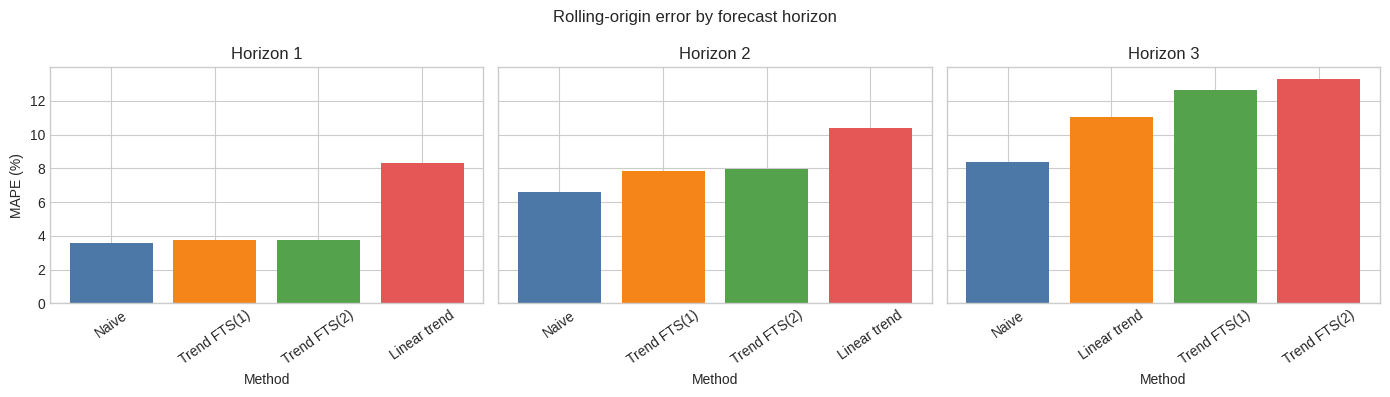

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for horizon, ax in zip(range(1, 4), axes):
    view = metrics[metrics["horizon"] == horizon]
    ax.bar(view["method"], view["MAPE (%)"], color=["#4c78a8", "#f58518", "#54a24b", "#e45756"])
    ax.set_title(f"Horizon {horizon}")
    ax.set_xlabel("Method")
    ax.tick_params(axis="x", rotation=35)
axes[0].set_ylabel("MAPE (%)")
fig.suptitle("Rolling-origin error by forecast horizon")
fig.tight_layout()
plt.show()

## 5. Concrete five-year forecast from 1987

Fit each method using observations through 1987 and predict **1988–1992 (five steps)**. This directly exposes the difference between a level-state FTS that can become horizontal and the trend-aware FTS used here: fuzzy change predictions are cumulatively added to the latest level. The plot is an interpretable example; the rolling table above remains the more reliable model comparison.

In [22]:
cutoff = 1987
steps = 5
train_mask = years <= cutoff
example_forecasts = forecast_methods(values[train_mask], steps=steps)
future_years = years[~train_mask][:steps]

example_table = pd.DataFrame({"Actual": values[~train_mask][:steps]}, index=future_years)
for method, forecast in example_forecasts.items():
    example_table[method] = forecast
example_table.round(1)

,Actual,Naive,Linear trend,Trend FTS(1),Trend FTS(2)
1988,18150.0,16859.0,16724.4,17514.3,17514.3
1989,18970.0,16859.0,16872.8,17647.2,17509.8
1990,19328.0,16859.0,17021.1,17805.9,17831.2
1991,19337.0,16859.0,17169.5,18543.6,18152.6
1992,18876.0,16859.0,17317.9,18676.5,19125.7


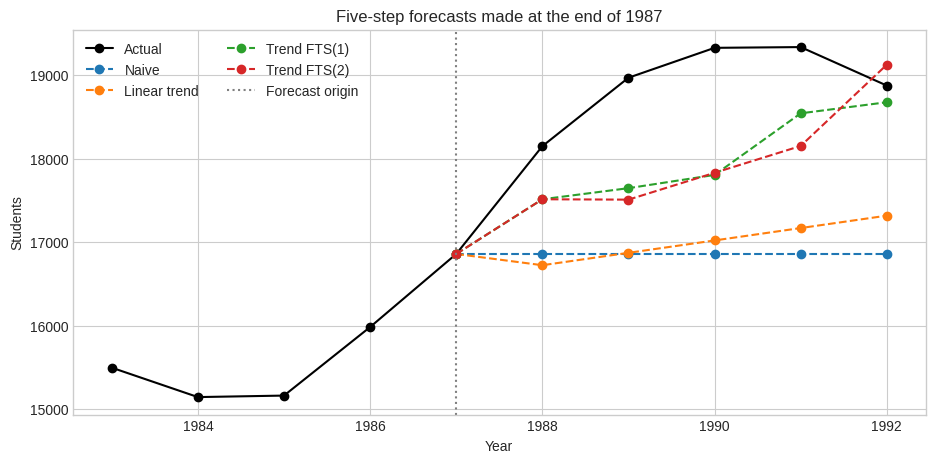

In [23]:
ax = series.loc[1983:].plot(marker="o", color="black", figsize=(11, 5), label="Actual")
for method, forecast in example_forecasts.items():
    ax.plot(
        np.r_[cutoff, future_years],
        np.r_[series.loc[cutoff], forecast],
        marker="o",
        linestyle="--",
        label=method,
    )
ax.axvline(cutoff, color="grey", linestyle=":", label="Forecast origin")
ax.set(title="Five-step forecasts made at the end of 1987", xlabel="Year", ylabel="Students")
ax.legend(ncol=2)
plt.show()

## 6. Interpretation and limitations

1. Compare methods **within each horizon** in the metrics table. The ranking is empirical and can differ as the horizon grows.
2. Unlike level-state FTS, Trend FTS forecasts a fuzzy annual change and integrates it into the last level. It can therefore preserve direction rather than becoming horizontal merely because a level interval maps to itself.
3. Recency decay makes the rules responsive to current motion. It does not guarantee that a trend continues: learned transitions can still predict a reversal, which is visible and inspectable in the change-rule table.
4. Second order is not automatically better. With only 22 levels (21 changes), state pairs are sparse, so the model may need its first-order fallback.
5. Recursive changes accumulate error. A linear trend extrapolates a global slope; persistence assumes no change. Their different assumptions explain their different paths.
6. Results depend on interval count, partition scheme, universe padding, and decay. Select these only inside a validation loop on a larger data set—not by looking at final test years.
7. Enrollment is positive and far from zero, so MAPE is safe here. For series containing zeros, prefer MAE/RMSE or a suitable scaled metric.

The experiment shows *how* the approaches behave rather than declaring a universal winner.